In [ ]:

from pathlib import Path

# =========================
# CONFIGURATION
# =========================

BASE_DIR = Path(r"./experiments_results/experiments_improved/checkpoints_improved/single_stage_improved/")
OUTPUT_DIR = BASE_DIR / "analysis_outputs_advanced_names"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

EXCLUDED_DIR_PREFIXES = ("experiments",)

TRAINING_HISTORY_FILENAME = "training_history.csv"
VAL_CM_FILENAME = "val_confusion_matrix_final_12class.csv"
TEST_CM_FILENAME = "test_confusion_matrix_final_12class.csv"

TARGET_WORDS = ["yes", "no", "up", "down", "left", "right", "on", "off", "stop", "go"]
CLASS_NAMES = ["background_noise"] + TARGET_WORDS + ["unknown"]

METRICS_TO_PLOT = [
    "train_loss",
    "val_loss",
    "val_macro_f1",
    "val_balanced_acc",
    "val_overall_acc",
    "lr",
]

SAVE_FIGURES = True
DPI = 220
FIG_EXTENSIONS = ("png", "pdf")

FONT_SIZE = 20
TITLE_SIZE = 28
LABEL_SIZE = 24
TICK_SIZE = 18
LEGEND_SIZE = 14
LEGEND_TITLE_SIZE = 16

SHOW_INDIVIDUAL_RUNS = True
SHOW_STD_BAND = True
LEGEND_LOCATION = "best"  # e.g. "best", "upper right", "lower right", "center right"
LEGEND_NCOL = 1

ANNOTATE_CM = True
NORMALIZE_CM = True
CM_CMAP = "Blues"
DIFF_CMAP = "coolwarm"

print("BASE_DIR:", BASE_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)


BASE_DIR: experiments_results\experiments_improved\checkpoints_improved\single_stage_improved
OUTPUT_DIR: experiments_results\experiments_improved\checkpoints_improved\single_stage_improved\analysis_outputs_advanced_names


In [33]:

import math
import re
from typing import Optional, Tuple, Dict, List, Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

plt.rcParams.update({
    "font.size": FONT_SIZE,
    "axes.titlesize": TITLE_SIZE,
    "axes.labelsize": LABEL_SIZE,
    "xtick.labelsize": TICK_SIZE,
    "ytick.labelsize": TICK_SIZE,
    "legend.fontsize": LEGEND_SIZE,
    "legend.title_fontsize": LEGEND_TITLE_SIZE,
    "figure.titlesize": TITLE_SIZE,
})


In [ ]:

# =========================
# ADVANCED FOLDER-NAME PARSER
# =========================

def clean_name(name: str) -> str:
    name = str(name).strip()
    name = re.sub(r"[\s\-]+", "_", name)
    name = re.sub(r"_+", "_", name)
    return name.strip("_")


def extract_seed(name: str):
    name = str(name)
    patterns = [
        r"(?i)(?:^|[_\-\s])seed[_\-\s]*(\d+)(?=$|[_\-\s])",
        r"(?i)(?:^|[_\-\s])(\d+)[_\-\s]*seed(?=$|[_\-\s])",
    ]
    for pat in patterns:
        m = re.search(pat, name)
        if m:
            return int(m.group(1)), m
    return np.nan, None


def remove_seed_from_name(name: str) -> str:
    seed, match = extract_seed(name)
    if match is None:
        return clean_name(name)
    method = name[:match.start()] + name[match.end():]
    return clean_name(method)


def parse_bool(value):
    if value is None:
        return None
    v = str(value).strip().lower()
    if v in {"true", "1", "yes", "y"}:
        return True
    if v in {"false", "0", "no", "n"}:
        return False
    return None


def parse_experiment_folder(folder_name: str) -> Dict[str, Any]:
    original = str(folder_name).strip()
    normalized = clean_name(original)
    seed, _ = extract_seed(normalized)
    method_key = remove_seed_from_name(normalized)
    low = method_key.lower()

    # Approach
    if "two_stage" in low:
        approach = "two_stage"
    elif "single_stage" in low:
        approach = "single_stage"
    else:
        approach = "unknown"

    # Model
    if re.search(r"(?:^|_)ast(?:_|$)", low):
        model = "AST"
    elif re.search(r"(?:^|_)lstm(?:_|$)", low):
        model = "LSTM"
    elif re.search(r"(?:^|_)cnn(?:_|$)", low):
        model = "CNN"
    else:
        model = "unknown"

    if "mfcc" in low:
        preprocessing = "mfcc"
    elif "mel" in low or "paper_shape" in low or "fbank" in low:
        preprocessing = "mel_spectrogram"
    else:
        preprocessing = "mel_spectrogram"

    if "speed" in low:
        augmentation = "speed_perturbation"
    elif "back" in low or "background" in low:
        augmentation = "background_noise"
    elif "spec" in low:
        augmentation = "spec_augment"
    elif "none" in low or "base" in low:
        augmentation = "none"
    elif "mfcc" in low:
        augmentation = "none"
    else:
        augmentation = "unknown"

    heads = None
    m = re.search(r"(?i)(?:^|_)heads?_?(\d+)(?=$|_)", low)
    if m:
        heads = int(m.group(1))

    dropout = None
    m = re.search(r"(?i)(?:^|_)(?:dp|dropout)_([0-9]*\.?[0-9]+)(?=$|_)", low)
    if m:
        dropout = float(m.group(1))

    learning_rate = None
    m = re.search(r"(?i)(?:^|_)lr_([0-9]+(?:\.[0-9]+)?(?:e[\+\-]?[0-9]+)?)(?=$|_)", low)
    if m:
        learning_rate = float(m.group(1))

    cosine_annealing = None
    m = re.search(r"(?i)(?:^|_)ca_(true|false|1|0|yes|no)(?=$|_)", low)
    if m:
        cosine_annealing = parse_bool(m.group(1))

    paper_shape = "paper_shape" in low

    info = {
        "original_name": original,
        "normalized_name": normalized,
        "method_key": method_key,
        "seed": seed,
        "approach": approach,
        "model": model,
        "preprocessing": preprocessing,
        "augmentation": augmentation,
        "heads": heads,
        "dropout": dropout,
        "learning_rate": learning_rate,
        "cosine_annealing": cosine_annealing,
        "paper_shape": paper_shape,
    }
    info["display_name"] = make_display_name_from_info(info)
    return info


def pretty_approach(x: str) -> str:
    return {
        "two_stage": "Two-stage",
        "single_stage": "Single-stage",
        "unknown": "Unknown-stage",
    }.get(x, x)


def pretty_preprocessing(x: str) -> str:
    return {
        "mfcc": "MFCC",
        "mel_spectrogram": "Mel spectrogram",
    }.get(x, x)


def pretty_augmentation(x: str) -> str:
    return {
        "none": "No augmentation",
        "spec_augment": "SpecAugment",
        "background_noise": "Background noise",
        "speed_perturbation": "Speed perturbation",
        "unknown": "Unknown augmentation",
    }.get(x, x)


def make_display_name_from_info(info: Dict[str, Any]) -> str:
    key = info.get("method_key")

    parts = []
    # parts.append(pretty_approach(info.get("approach", "unknown")))

    # model = info.get("model")
    # if model and model != "unknown":
    #     parts.append(model)

    # core = f"{pretty_preprocessing(info.get('preprocessing'))} + {pretty_augmentation(info.get('augmentation'))}"
    # parts.append(core)

    extra = []
    # if info.get("heads") is not None:
    #     parts.append(f"{info['heads']}")
    # else:
    #     parts.append(f"12")
    # if info.get("dropout") is not None:
    #     parts.append(f"{info['dropout']}")
    # if info.get("learning_rate") is not None:
    #     parts.append(f"LR={info['learning_rate']:.0e}")
    # if info.get("cosine_annealing") is True:
    #     parts.append(f"CA=True")
    # else: 
    #     parts.append(f"CA=False")
    # elif info.get("cosine_annealing") is False:
    #     extra.append("no cosine annealing")
    # print(info.get("approach"))
    if info.get("approach") is not None:
        parts.append(f"{info['approach']}")

    label = " · ".join(parts)
    if extra:
        label += " (" + ", ".join(extra) + ")"
    return label


def should_exclude_path(path: Path, excluded_prefixes=EXCLUDED_DIR_PREFIXES) -> bool:
    for part in path.parts:
        lower = part.lower()
        for prefix in excluded_prefixes:
            if lower.startswith(prefix.lower()):
                return True
    return False


def find_nearest_seed_folder(path: Path, base_dir: Path) -> Dict[str, Any]:
    current = path.parent
    base_resolved = base_dir.resolve()
    while True:
        info = parse_experiment_folder(current.name)
        if not pd.isna(info["seed"]):
            return info
        if current.resolve() == base_resolved or current.parent == current:
            break
        current = current.parent
    return parse_experiment_folder(path.parent.name)


# Quick parser sanity check
examples = [
    "two_stage_ast_mfcc_spec_heads12_seed_267",
    "two_stage_ast_mfcc_spec_heads8_seed_167",
    "two_stage_ast_mfcc_none_lr_1e-05_ca_True_seed_267",
    "two_stage_ast_mfcc_none_dp_0.3_seed_67",
    "single_stage_ast_mfcc_none_seed_67",
]

for ex in examples:
    info = parse_experiment_folder(ex)
    print(ex)
    print("  method_key:", info["method_key"])
    print("  seed:", info["seed"])
    print("  display:", info["display_name"])


two_stage_ast_mfcc_spec_heads12_seed_267
  method_key: two_stage_ast_mfcc_spec_heads12
  seed: 267
  display: two_stage
two_stage_ast_mfcc_spec_heads8_seed_167
  method_key: two_stage_ast_mfcc_spec_heads8
  seed: 167
  display: two_stage
two_stage_ast_mfcc_none_lr_1e-05_ca_True_seed_267
  method_key: two_stage_ast_mfcc_none_lr_1e_05_ca_True
  seed: 267
  display: two_stage
two_stage_ast_mfcc_none_dp_0.3_seed_67
  method_key: two_stage_ast_mfcc_none_dp_0.3
  seed: 67
  display: two_stage
single_stage_ast_mfcc_none_seed_67
  method_key: single_stage_ast_mfcc_none
  seed: 67
  display: single_stage


In [35]:

# =========================
# FILE DISCOVERY
# =========================

def discover_files(base_dir: Path, filename: str):
    all_paths = sorted(base_dir.rglob(filename))
    kept, skipped = [], []
    for p in all_paths:
        rel = p.relative_to(base_dir)
        if should_exclude_path(rel):
            skipped.append(p)
        else:
            kept.append(p)
    return kept, skipped

history_paths, skipped_history_paths = discover_files(BASE_DIR, TRAINING_HISTORY_FILENAME)
val_cm_paths, skipped_val_cm_paths = discover_files(BASE_DIR, VAL_CM_FILENAME)
test_cm_paths, skipped_test_cm_paths = discover_files(BASE_DIR, TEST_CM_FILENAME)

print(f"training histories: found={len(history_paths) + len(skipped_history_paths)}, kept={len(history_paths)}, skipped={len(skipped_history_paths)}")
print(f"val confusion matrices: found={len(val_cm_paths) + len(skipped_val_cm_paths)}, kept={len(val_cm_paths)}, skipped={len(skipped_val_cm_paths)}")
print(f"test confusion matrices: found={len(test_cm_paths) + len(skipped_test_cm_paths)}, kept={len(test_cm_paths)}, skipped={len(skipped_test_cm_paths)}")

if len(history_paths) == 0 and len(skipped_history_paths) > 0:
    print("\nFirst skipped history files:")
    for p in skipped_history_paths[:10]:
        print("  ", p)


training histories: found=6, kept=6, skipped=0
val confusion matrices: found=3, kept=3, skipped=0
test confusion matrices: found=6, kept=6, skipped=0


In [36]:

# =========================
# LOAD TRAINING HISTORIES
# =========================

def load_all_histories(paths: List[Path], base_dir: Path) -> pd.DataFrame:
    rows = []
    for p in paths:
        try:
            df = pd.read_csv(p)
        except Exception as e:
            print(f"[WARN] Could not read {p}: {e}")
            continue

        info = find_nearest_seed_folder(p, base_dir)
        for k, v in info.items():
            if k == "original_name":
                continue
            df[k] = v
        df["run_folder"] = p.parent.name
        df["history_path"] = str(p)
        rows.append(df)

    if not rows:
        return pd.DataFrame()

    all_df = pd.concat(rows, ignore_index=True)

    numeric_cols = [
        "epoch", "train_loss", "lr", "val_loss", "val_macro_f1",
        "val_balanced_acc", "val_overall_acc", "val_count", "seed",
        "heads", "dropout", "learning_rate"
    ]
    for col in numeric_cols:
        if col in all_df.columns:
            all_df[col] = pd.to_numeric(all_df[col], errors="coerce")

    all_df = all_df.sort_values(["method_key", "seed", "epoch"]).reset_index(drop=True)
    return all_df

all_histories = load_all_histories(history_paths, BASE_DIR)

if all_histories.empty:
    print("[WARN] No training history data loaded.")
else:
    display_cols = [
        "method_key", "display_name", "seed", "approach", "model", "preprocessing",
        "augmentation", "heads", "dropout", "learning_rate", "cosine_annealing", "run_folder"
    ]
    display(
        all_histories[display_cols]
        .drop_duplicates()
        .sort_values(["method_key", "seed"])
        .reset_index(drop=True)
    )
    print("Number of methods:", all_histories["method_key"].nunique())
    print("Number of runs:", all_histories[["method_key", "seed"]].drop_duplicates().shape[0])


,method_key,display_name,seed,approach,model,preprocessing,augmentation,heads,dropout,learning_rate,cosine_annealing,run_folder
0,single_stage_ast_mfcc_none,single_stage,67,single_stage,AST,mfcc,none,NaN,NaN,NaN,None,single_stage_ast_mfcc_none_seed_67
1,single_stage_ast_mfcc_none,single_stage,167,single_stage,AST,mfcc,none,NaN,NaN,NaN,None,single_stage_ast_mfcc_none_seed_167
2,single_stage_ast_mfcc_none,single_stage,267,single_stage,AST,mfcc,none,NaN,NaN,NaN,None,single_stage_ast_mfcc_none_seed_267
3,two_stage_ast_mfcc_none,two_stage,67,two_stage,AST,mfcc,none,NaN,NaN,NaN,None,two_stage_ast_mfcc_none_seed_67
4,two_stage_ast_mfcc_none,two_stage,167,two_stage,AST,mfcc,none,NaN,NaN,NaN,None,two_stage_ast_mfcc_none_seed_167
5,two_stage_ast_mfcc_none,two_stage,267,two_stage,AST,mfcc,none,NaN,NaN,NaN,None,two_stage_ast_mfcc_none_seed_267


Number of methods: 2
Number of runs: 6


In [37]:

# =========================
# AGGREGATION ACROSS SEEDS ONLY
# =========================

def aggregate_histories(all_df: pd.DataFrame, metrics: List[str]) -> pd.DataFrame:
    if all_df.empty:
        return pd.DataFrame()

    group_cols = [
        "method_key", "display_name", "approach", "model", "preprocessing", "augmentation",
        "heads", "dropout", "learning_rate", "cosine_annealing", "epoch"
    ]

    agg_spec = {}
    for metric in metrics:
        if metric in all_df.columns:
            agg_spec[metric] = ["mean", "std", "min", "max", "count"]

    grouped = all_df.groupby(group_cols, dropna=False).agg(agg_spec)
    grouped.columns = [f"{metric}_{stat}" for metric, stat in grouped.columns]
    grouped = grouped.reset_index()

    seed_counts = (
        all_df.groupby(["method_key", "epoch"])["seed"]
        .nunique()
        .rename("n_seeds")
        .reset_index()
    )
    grouped = grouped.merge(seed_counts, on=["method_key", "epoch"], how="left")
    return grouped

agg_histories = aggregate_histories(all_histories, METRICS_TO_PLOT)

if not agg_histories.empty:
    display(agg_histories.head())
    all_histories.to_csv(OUTPUT_DIR / "all_training_histories_long.csv", index=False)
    agg_histories.to_csv(OUTPUT_DIR / "aggregated_training_histories.csv", index=False)
    print("Saved history CSV files to:", OUTPUT_DIR)


,method_key,display_name,approach,model,preprocessing,augmentation,heads,dropout,learning_rate,cosine_annealing,...,val_overall_acc_std,val_overall_acc_min,val_overall_acc_max,val_overall_acc_count,lr_mean,lr_std,lr_min,lr_max,lr_count,n_seeds
0,single_stage_ast_mfcc_none,single_stage,single_stage,AST,mfcc,none,NaN,NaN,NaN,NaN,...,0.005029,0.839877,0.849778,3,0.000100,0.0,0.000100,0.000100,3,3
1,single_stage_ast_mfcc_none,single_stage,single_stage,AST,mfcc,none,NaN,NaN,NaN,NaN,...,0.021938,0.835097,0.876408,3,0.000099,0.0,0.000099,0.000099,3,3
2,single_stage_ast_mfcc_none,single_stage,single_stage,AST,mfcc,none,NaN,NaN,NaN,NaN,...,0.005551,0.884602,0.895186,3,0.000096,0.0,0.000096,0.000096,3,3
3,single_stage_ast_mfcc_none,single_stage,single_stage,AST,mfcc,none,NaN,NaN,NaN,NaN,...,0.011438,0.880164,0.902697,3,0.000090,0.0,0.000090,0.000090,3,3
4,single_stage_ast_mfcc_none,single_stage,single_stage,AST,mfcc,none,NaN,NaN,NaN,NaN,...,0.005834,0.893479,0.905087,3,0.000083,0.0,0.000083,0.000083,3,3


Saved history CSV files to: experiments_results\experiments_improved\checkpoints_improved\single_stage_improved\analysis_outputs_advanced_names


In [ ]:

# =========================
# PLOT STYLES
# =========================

DISTINCT_COLORS = [
    "#0072B2", "#D55E00", "#009E73", "#CC79A7", "#E69F00",
    "#56B4E9", "#7E57C2", "#8E44AD", "#2C3E50", "#F39C12",
    "#16A085", "#C0392B", "#34495E", "#27AE60", "#2980B9",
]

LINESTYLE_MAP = {
    "none": "-",
    "background_noise": "--",
    "spec_augment": "-.",
    "speed_perturbation": ":",
    "unknown": (0, (1, 1)),
}

MARKER_BY_APPROACH = {
    "two_stage": "o",
    "single_stage": "s",
    "unknown": "D",
}

metric_titles = {
    "train_loss": "Training loss",
    "val_loss": "Validation loss",
    "val_macro_f1": "Validation macro F1",
    "val_balanced_acc": "Validation balanced accuracy",
    "val_overall_acc": "Validation overall accuracy",
    "lr": "Learning rate",
}


def make_method_color_map(all_df: pd.DataFrame) -> Dict[str, str]:
    methods = sorted(all_df["method_key"].dropna().unique()) if not all_df.empty else []
    return {m: DISTINCT_COLORS[i % len(DISTINCT_COLORS)] for i, m in enumerate(methods)}

METHOD_COLOR_MAP = make_method_color_map(all_histories)


def get_method_style(method_key: str, approach: str, augmentation: str):
    color = METHOD_COLOR_MAP.get(method_key, "#333333")
    linestyle = LINESTYLE_MAP.get(augmentation, "-")
    marker = MARKER_BY_APPROACH.get(approach, "o")
    return color, linestyle, marker


def save_figure(base_path: Path):
    if not SAVE_FIGURES:
        return
    for ext in FIG_EXTENSIONS:
        out = base_path.with_suffix(f".{ext}")
        plt.savefig(out, dpi=DPI if ext == "png" else None, bbox_inches="tight")
        print("Saved:", out)


Saved: experiments_results\experiments_improved\checkpoints_improved\single_stage_improved\analysis_outputs_advanced_names\trajectory_train_loss.png
Saved: experiments_results\experiments_improved\checkpoints_improved\single_stage_improved\analysis_outputs_advanced_names\trajectory_train_loss.pdf


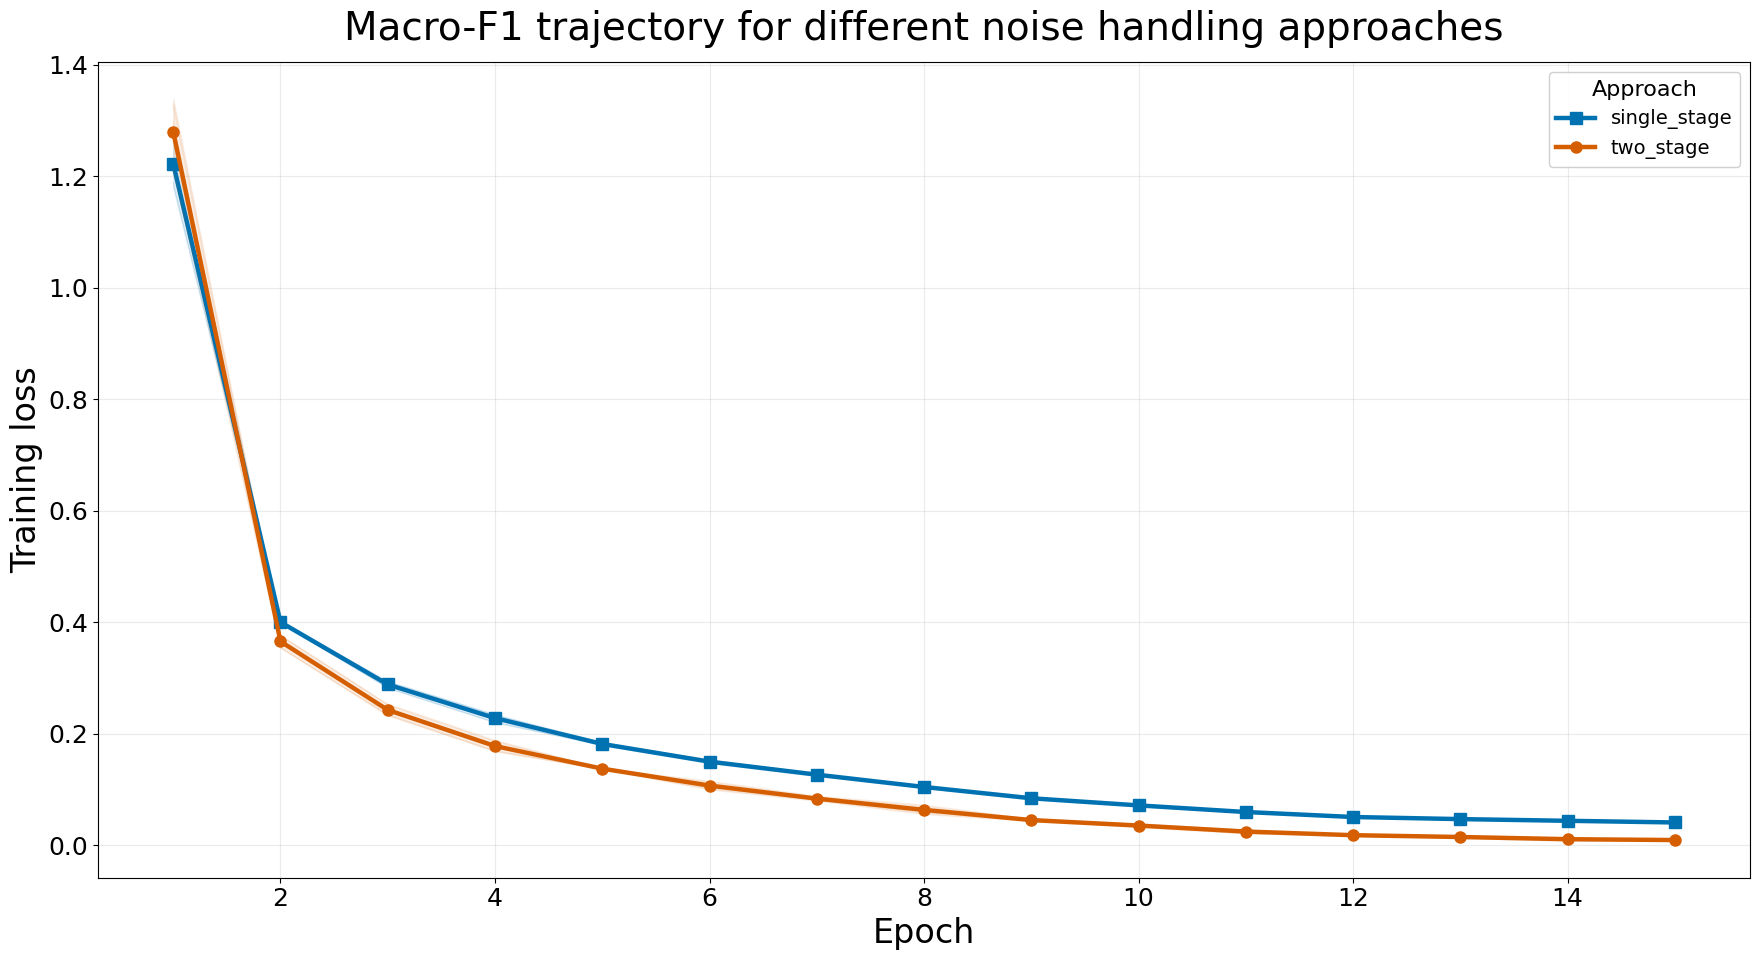

Saved: experiments_results\experiments_improved\checkpoints_improved\single_stage_improved\analysis_outputs_advanced_names\trajectory_val_loss.png
Saved: experiments_results\experiments_improved\checkpoints_improved\single_stage_improved\analysis_outputs_advanced_names\trajectory_val_loss.pdf


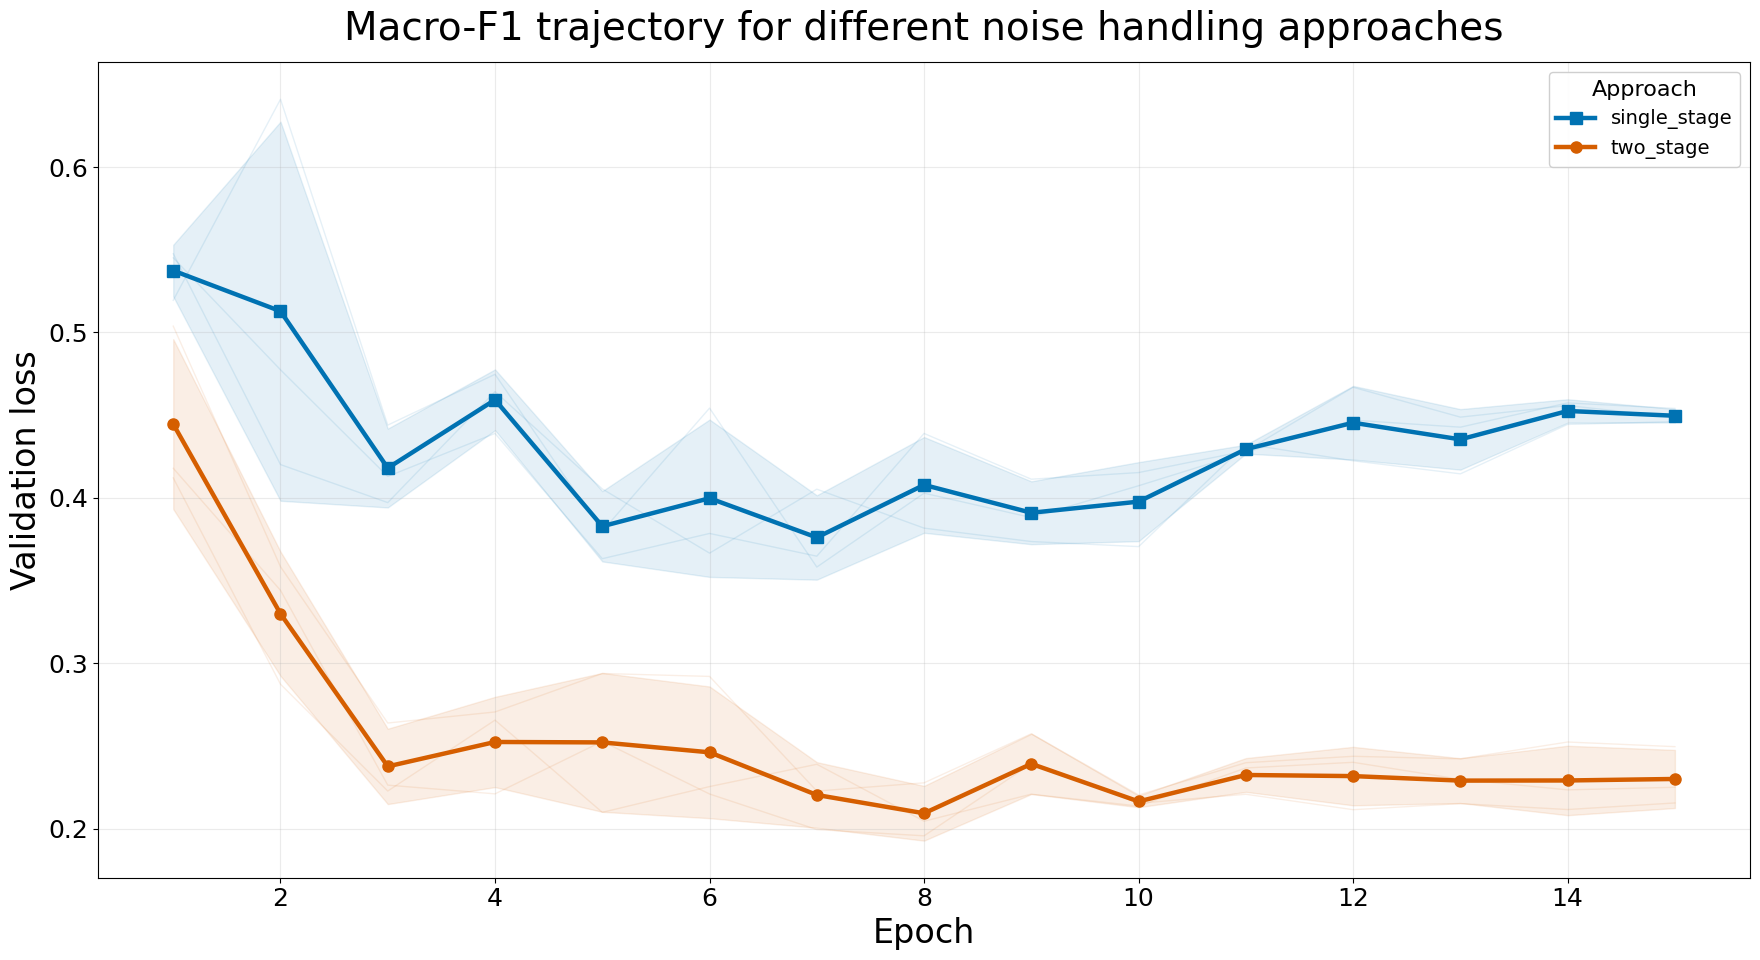

Saved: experiments_results\experiments_improved\checkpoints_improved\single_stage_improved\analysis_outputs_advanced_names\trajectory_val_macro_f1.png
Saved: experiments_results\experiments_improved\checkpoints_improved\single_stage_improved\analysis_outputs_advanced_names\trajectory_val_macro_f1.pdf


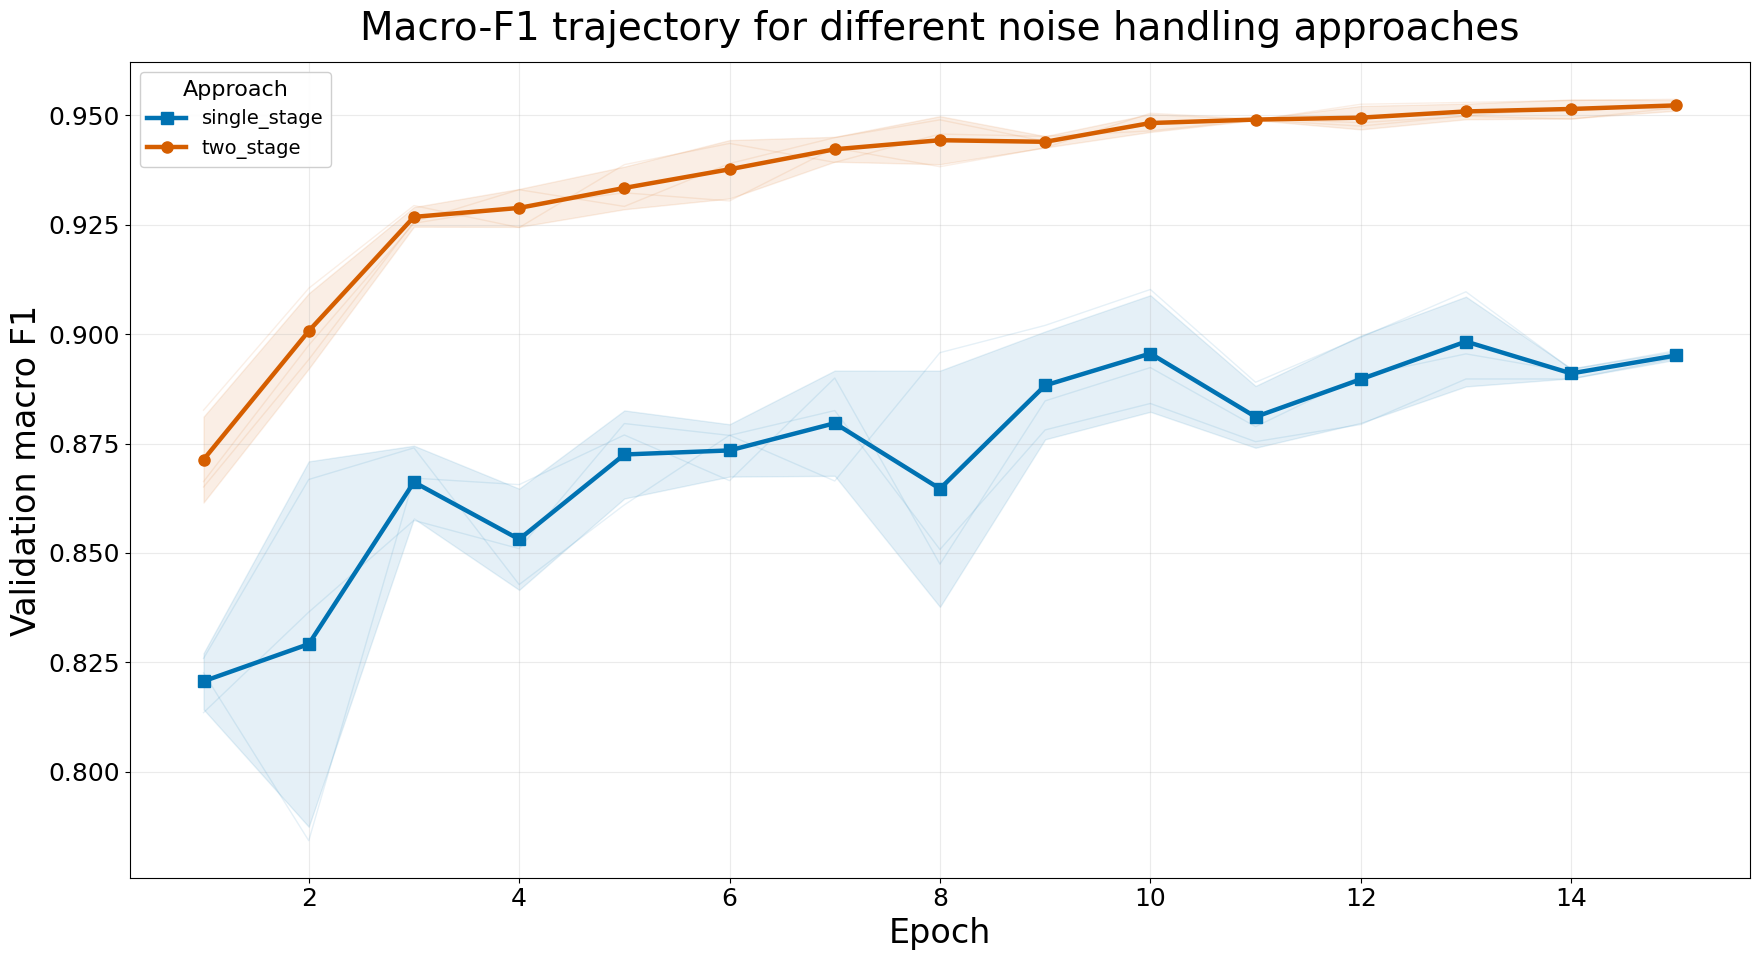

Saved: experiments_results\experiments_improved\checkpoints_improved\single_stage_improved\analysis_outputs_advanced_names\trajectory_val_balanced_acc.png
Saved: experiments_results\experiments_improved\checkpoints_improved\single_stage_improved\analysis_outputs_advanced_names\trajectory_val_balanced_acc.pdf


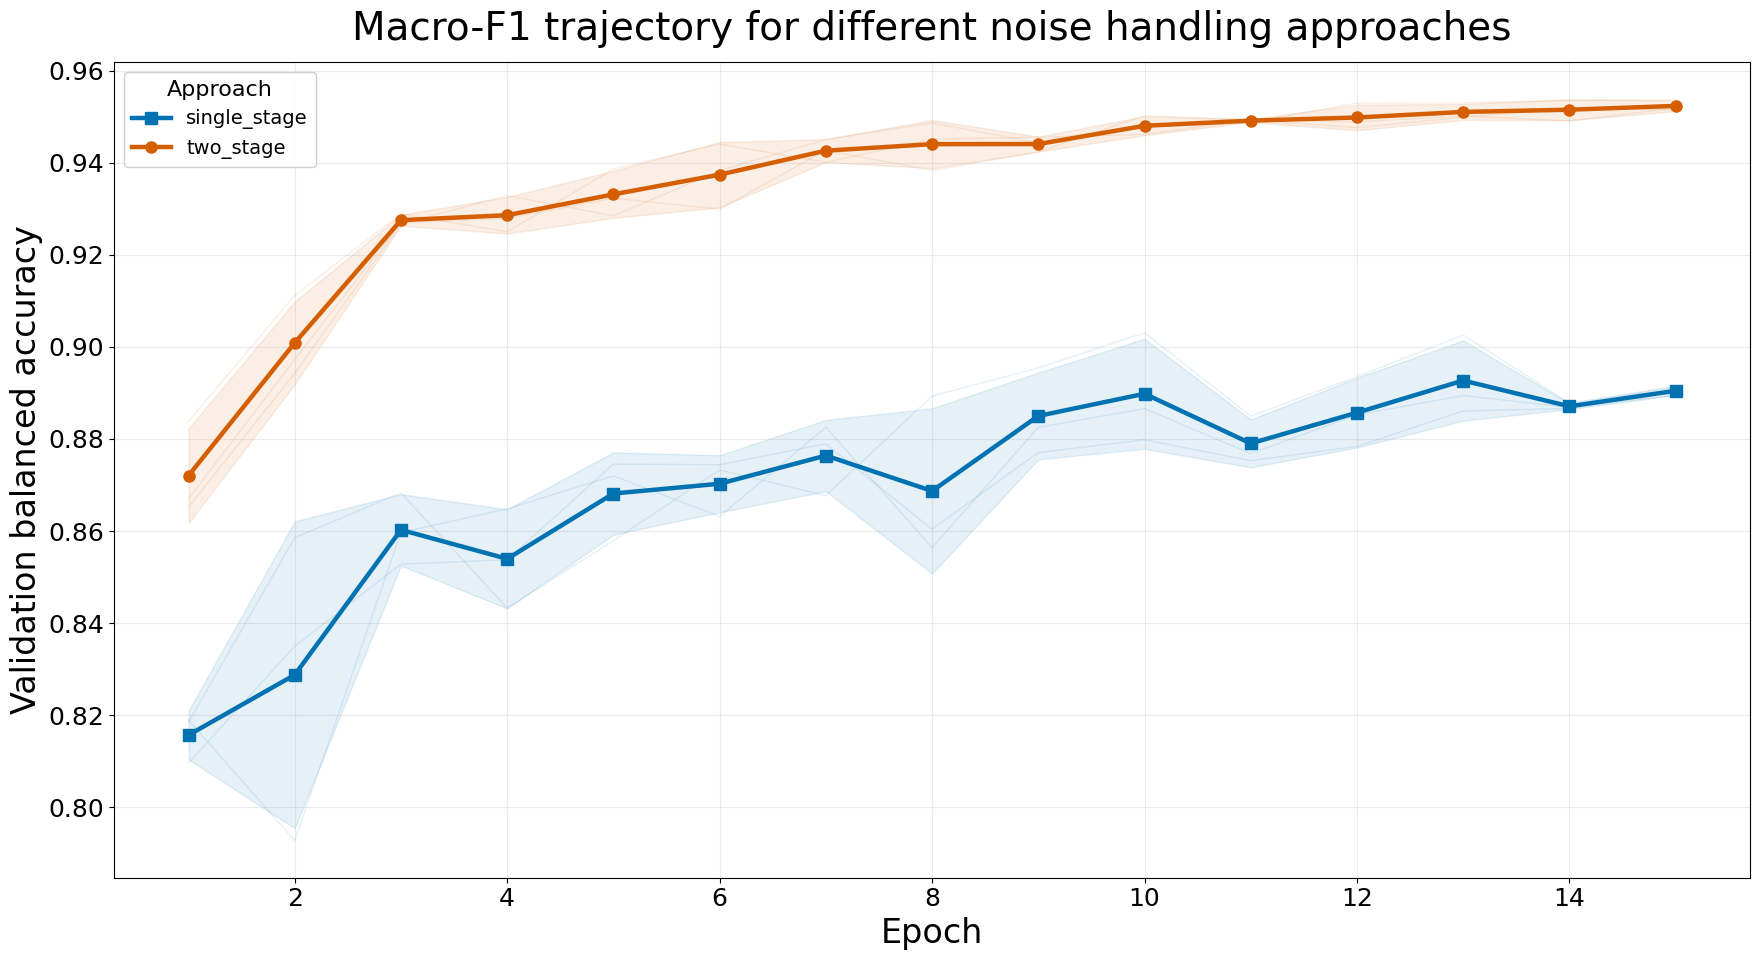

Saved: experiments_results\experiments_improved\checkpoints_improved\single_stage_improved\analysis_outputs_advanced_names\trajectory_val_overall_acc.png
Saved: experiments_results\experiments_improved\checkpoints_improved\single_stage_improved\analysis_outputs_advanced_names\trajectory_val_overall_acc.pdf


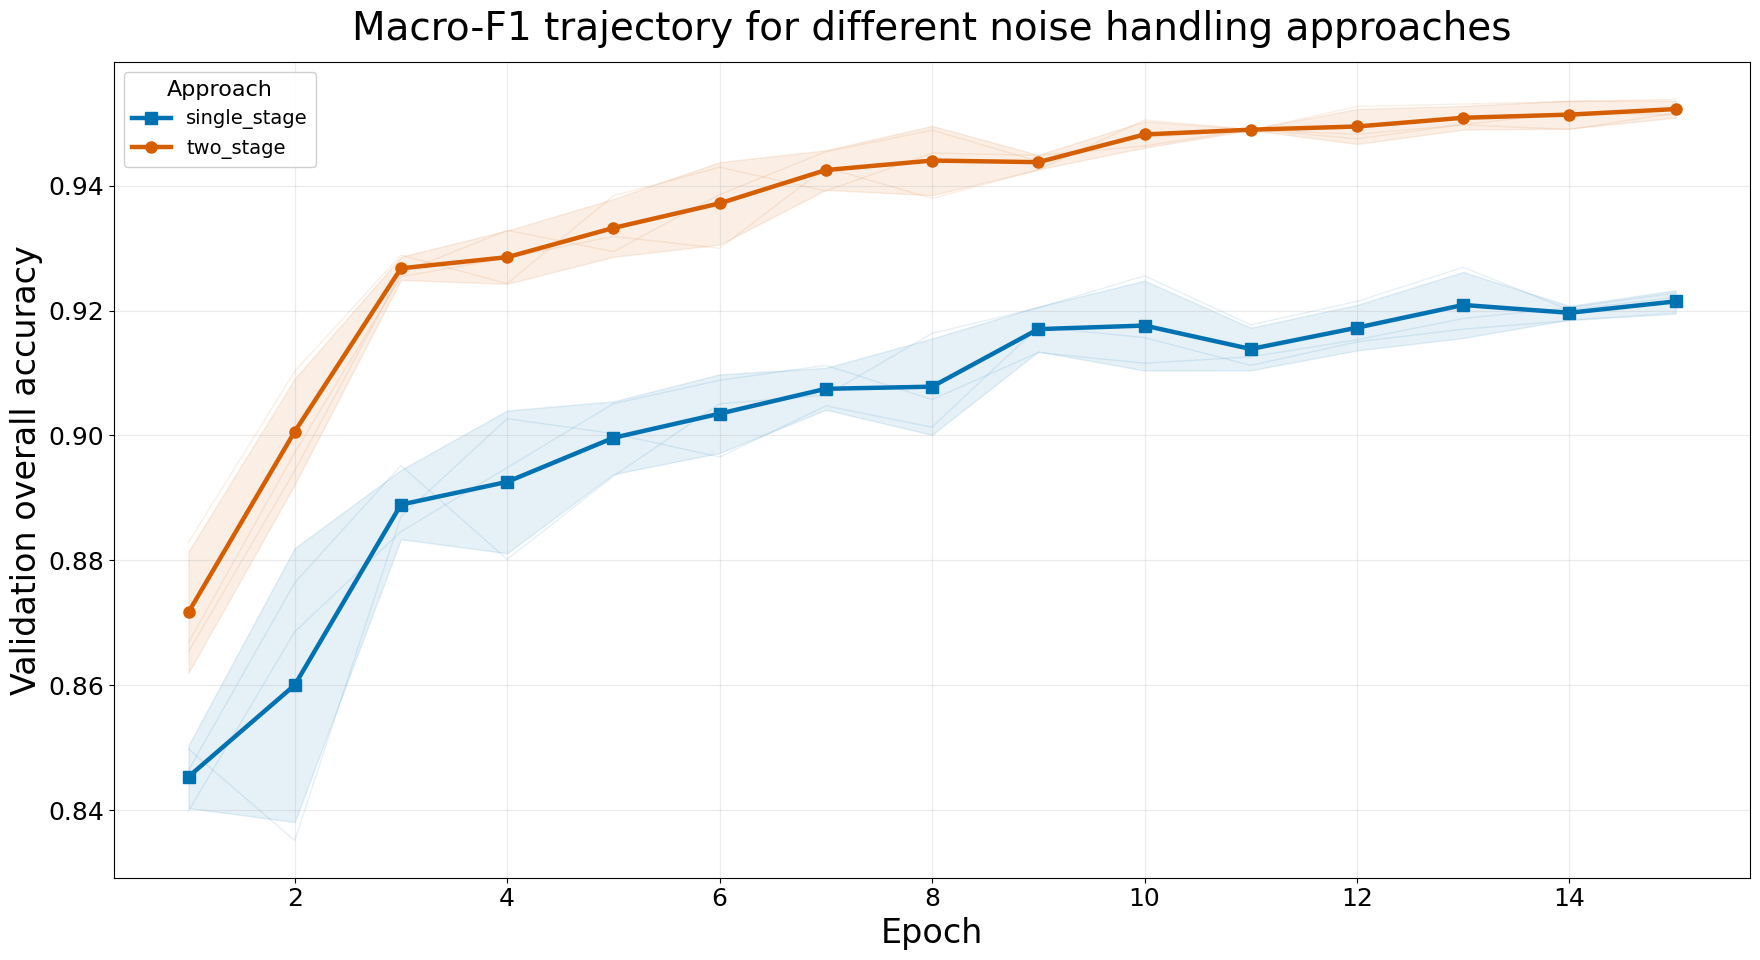

Saved: experiments_results\experiments_improved\checkpoints_improved\single_stage_improved\analysis_outputs_advanced_names\trajectory_lr.png
Saved: experiments_results\experiments_improved\checkpoints_improved\single_stage_improved\analysis_outputs_advanced_names\trajectory_lr.pdf


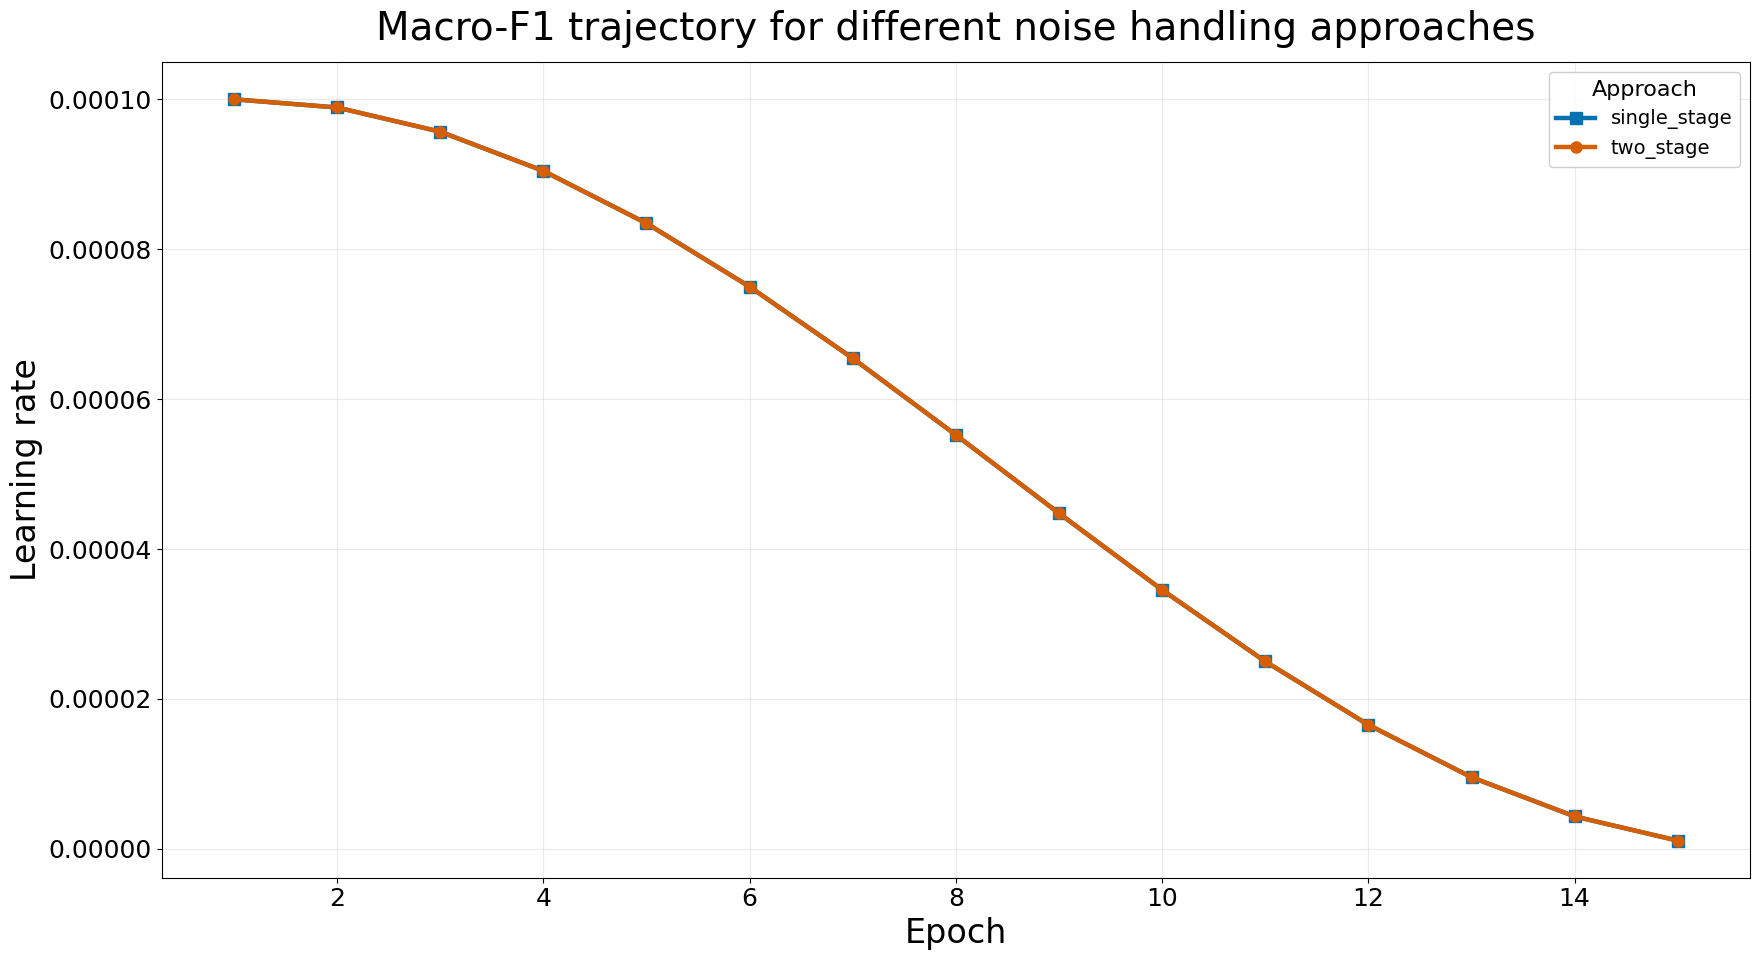

In [44]:

# =========================
# TRAJECTORY PLOTS
# =========================

def plot_metric_trajectories(
    all_df,
    agg_df,
    metric,
    output_dir=None,
    show_individual_runs=True,
    show_std_band=True,
    figsize=(18, 10),
):
    if all_df.empty or agg_df.empty or metric not in all_df.columns:
        print(f"[WARN] Cannot plot {metric}.")
        return

    y_label = metric_titles.get(metric, metric)

    methods_meta = (
        all_df[["method_key", "display_name", "approach", "augmentation"]]
        .drop_duplicates()
        .sort_values(["display_name"])
        .reset_index(drop=True)
    )

    fig, ax = plt.subplots(figsize=figsize)
    handles = []
    used_labels = set()

    for _, row in methods_meta.iterrows():
        method_key = row["method_key"]
        display_name = row["display_name"]
        approach = row["approach"]
        augmentation = row["augmentation"]
        color, linestyle, marker = get_method_style(method_key, approach, augmentation)

        method_runs = all_df[all_df["method_key"] == method_key].sort_values(["seed", "epoch"])
        method_agg = agg_df[agg_df["method_key"] == method_key].sort_values("epoch")

        if show_individual_runs:
            for _, seed_df in method_runs.groupby("seed"):
                ax.plot(
                    seed_df["epoch"], seed_df[metric],
                    color=color, alpha=0.10, linewidth=1.0, linestyle=linestyle,
                )

        mean_col = f"{metric}_mean"
        std_col = f"{metric}_std"
        if mean_col not in method_agg.columns:
            continue

        x = method_agg["epoch"].to_numpy()
        y = method_agg[mean_col].to_numpy()
        std = method_agg[std_col].fillna(0).to_numpy() if std_col in method_agg.columns else np.zeros_like(y)

        line, = ax.plot(
            x, y,
            color=color,
            linestyle=linestyle,
            marker=marker,
            markersize=8,
            linewidth=3.2,
            label=display_name,
        )

        if display_name not in used_labels:
            handles.append(line)
            used_labels.add(display_name)

        if show_std_band:
            ax.fill_between(x, y - std, y + std, color=color, alpha=0.10)

    ax.set_title("Macro-F1 trajectory for different noise handling approaches", pad=16)
    ax.set_xlabel("Epoch")
    ax.set_ylabel(y_label)
    ax.tick_params(axis="both")
    ax.grid(True, alpha=0.25)

    ax.legend(
        handles=handles,
        title="Approach",
        loc=LEGEND_LOCATION,
        ncol=LEGEND_NCOL,
        frameon=True,
        framealpha=0.93,
        fancybox=True,
    )

    plt.tight_layout()
    if output_dir is not None:
        save_figure(Path(output_dir) / f"trajectory_{metric}")
    plt.show()


for metric in METRICS_TO_PLOT:
    plot_metric_trajectories(
        all_histories,
        agg_histories,
        metric=metric,
        output_dir=OUTPUT_DIR,
        show_individual_runs=SHOW_INDIVIDUAL_RUNS,
        show_std_band=SHOW_STD_BAND,
    )


Saved: experiments_results\experiments_improved\checkpoints_improved\single_stage_improved\analysis_outputs_advanced_names\final_epoch_comparison_val_macro_f1.png
Saved: experiments_results\experiments_improved\checkpoints_improved\single_stage_improved\analysis_outputs_advanced_names\final_epoch_comparison_val_macro_f1.pdf


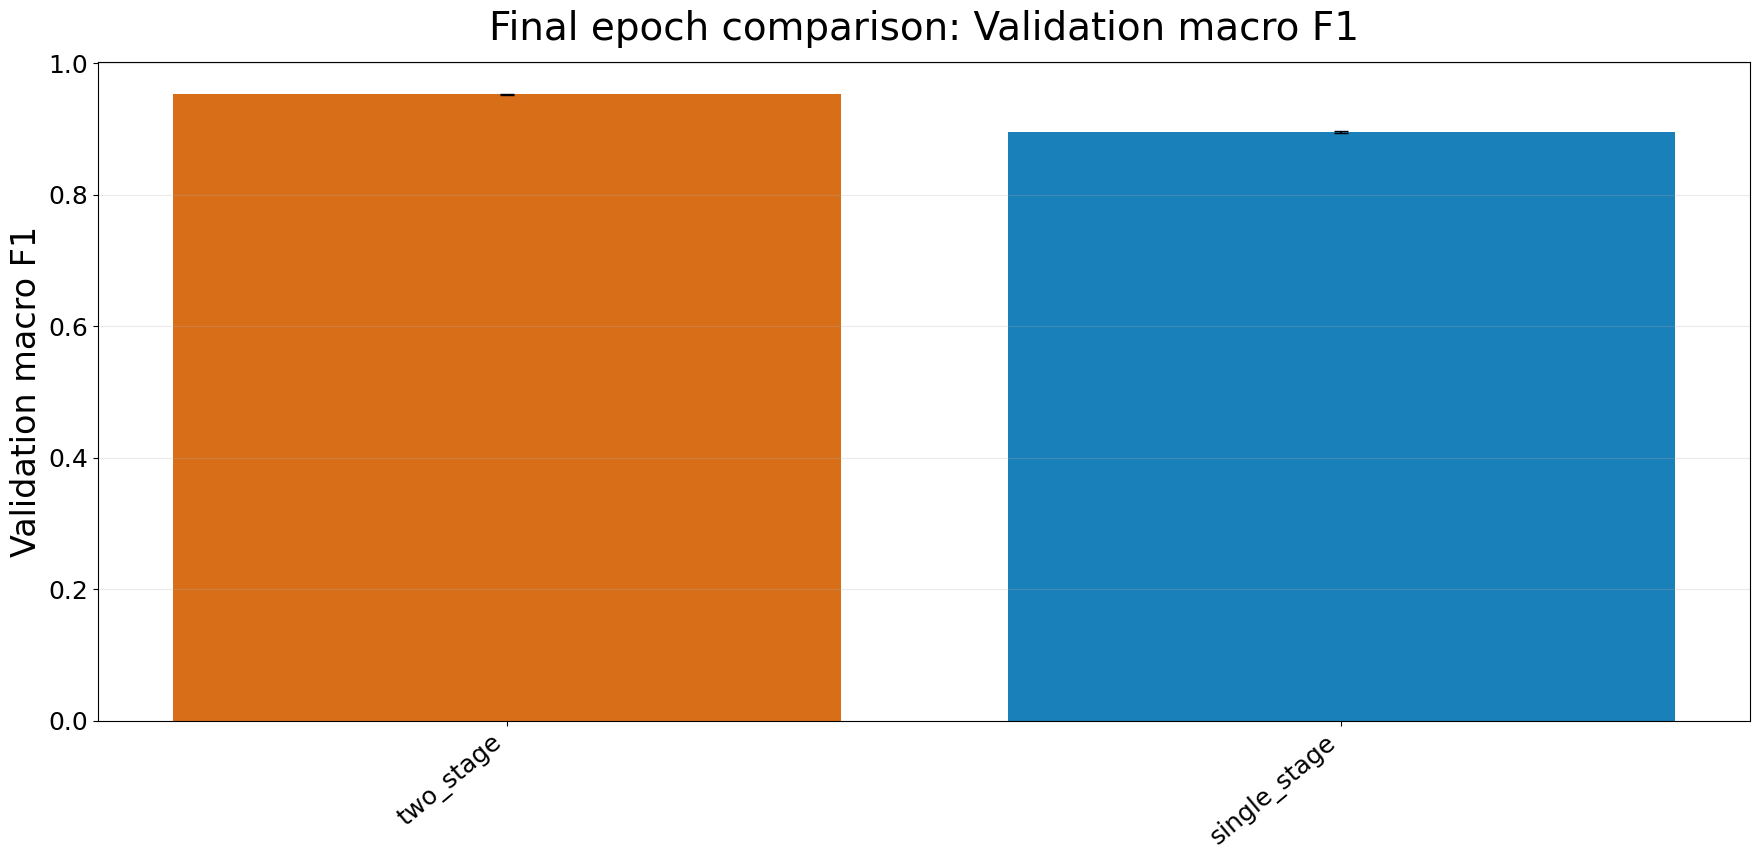

Saved: experiments_results\experiments_improved\checkpoints_improved\single_stage_improved\analysis_outputs_advanced_names\final_epoch_comparison_val_balanced_acc.png
Saved: experiments_results\experiments_improved\checkpoints_improved\single_stage_improved\analysis_outputs_advanced_names\final_epoch_comparison_val_balanced_acc.pdf


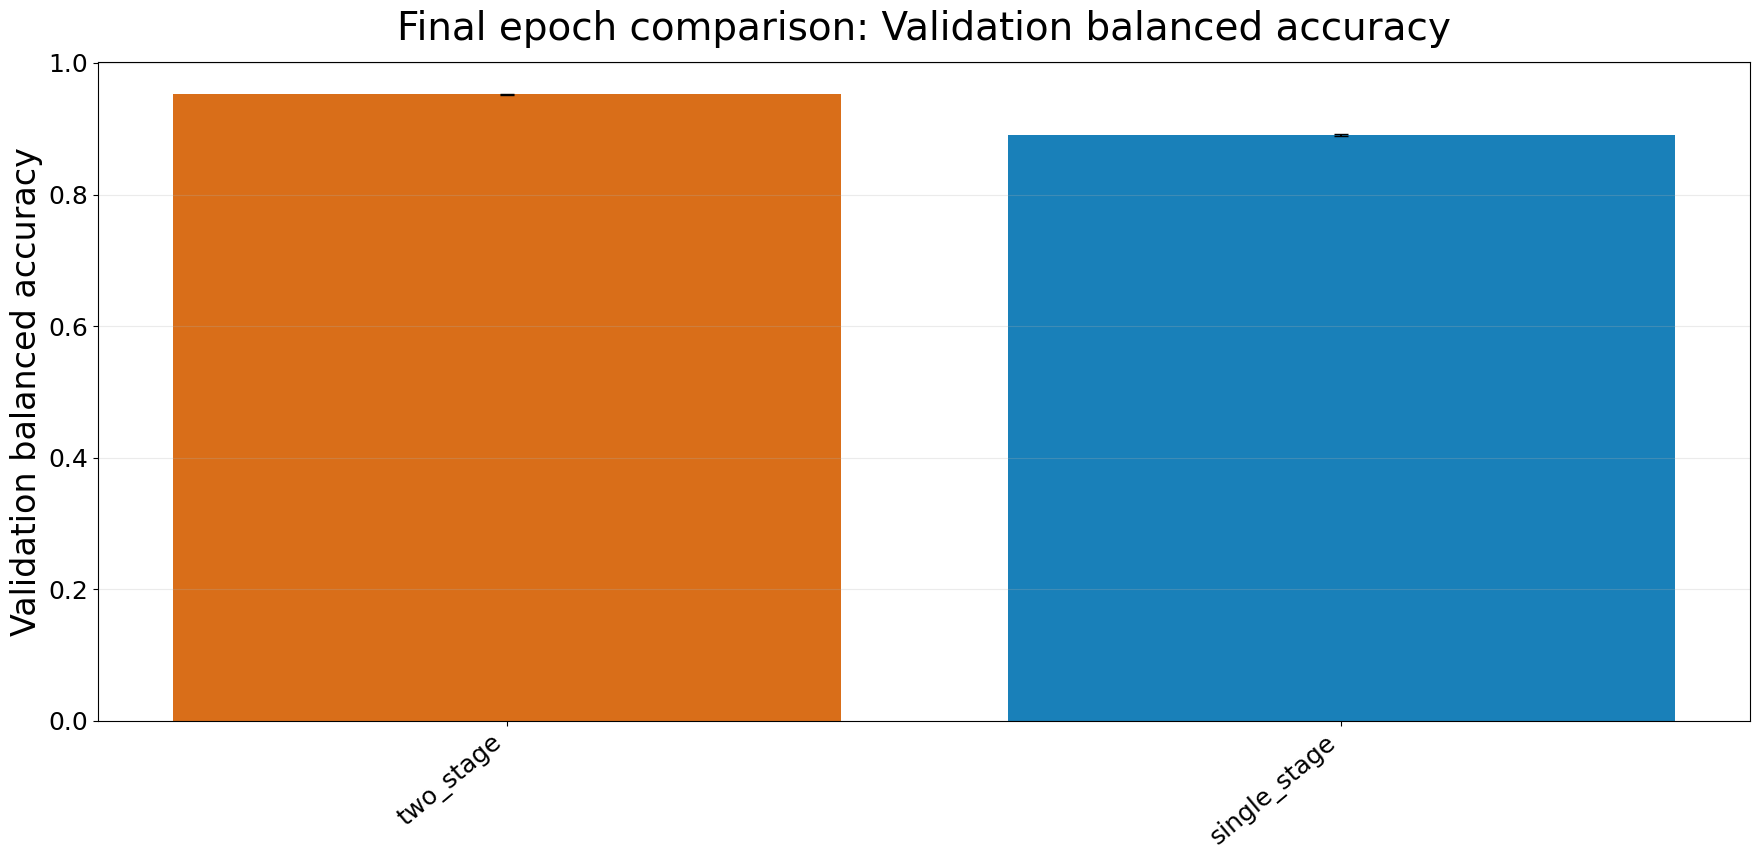

Saved: experiments_results\experiments_improved\checkpoints_improved\single_stage_improved\analysis_outputs_advanced_names\final_epoch_comparison_val_overall_acc.png
Saved: experiments_results\experiments_improved\checkpoints_improved\single_stage_improved\analysis_outputs_advanced_names\final_epoch_comparison_val_overall_acc.pdf


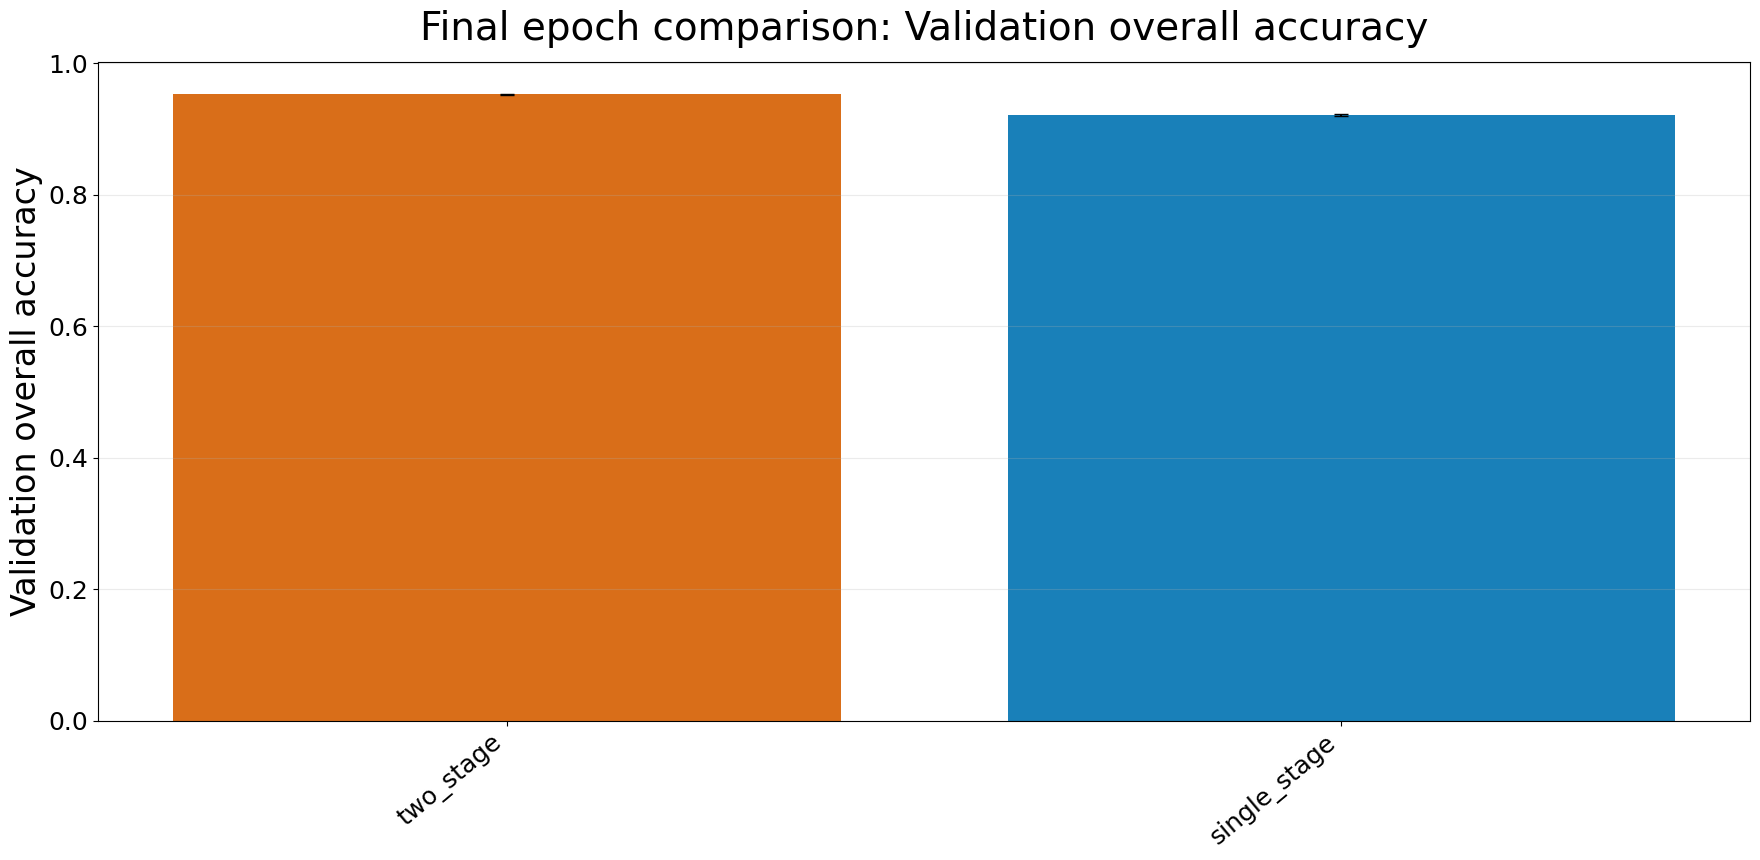

Saved: experiments_results\experiments_improved\checkpoints_improved\single_stage_improved\analysis_outputs_advanced_names\final_epoch_comparison_val_loss.png
Saved: experiments_results\experiments_improved\checkpoints_improved\single_stage_improved\analysis_outputs_advanced_names\final_epoch_comparison_val_loss.pdf


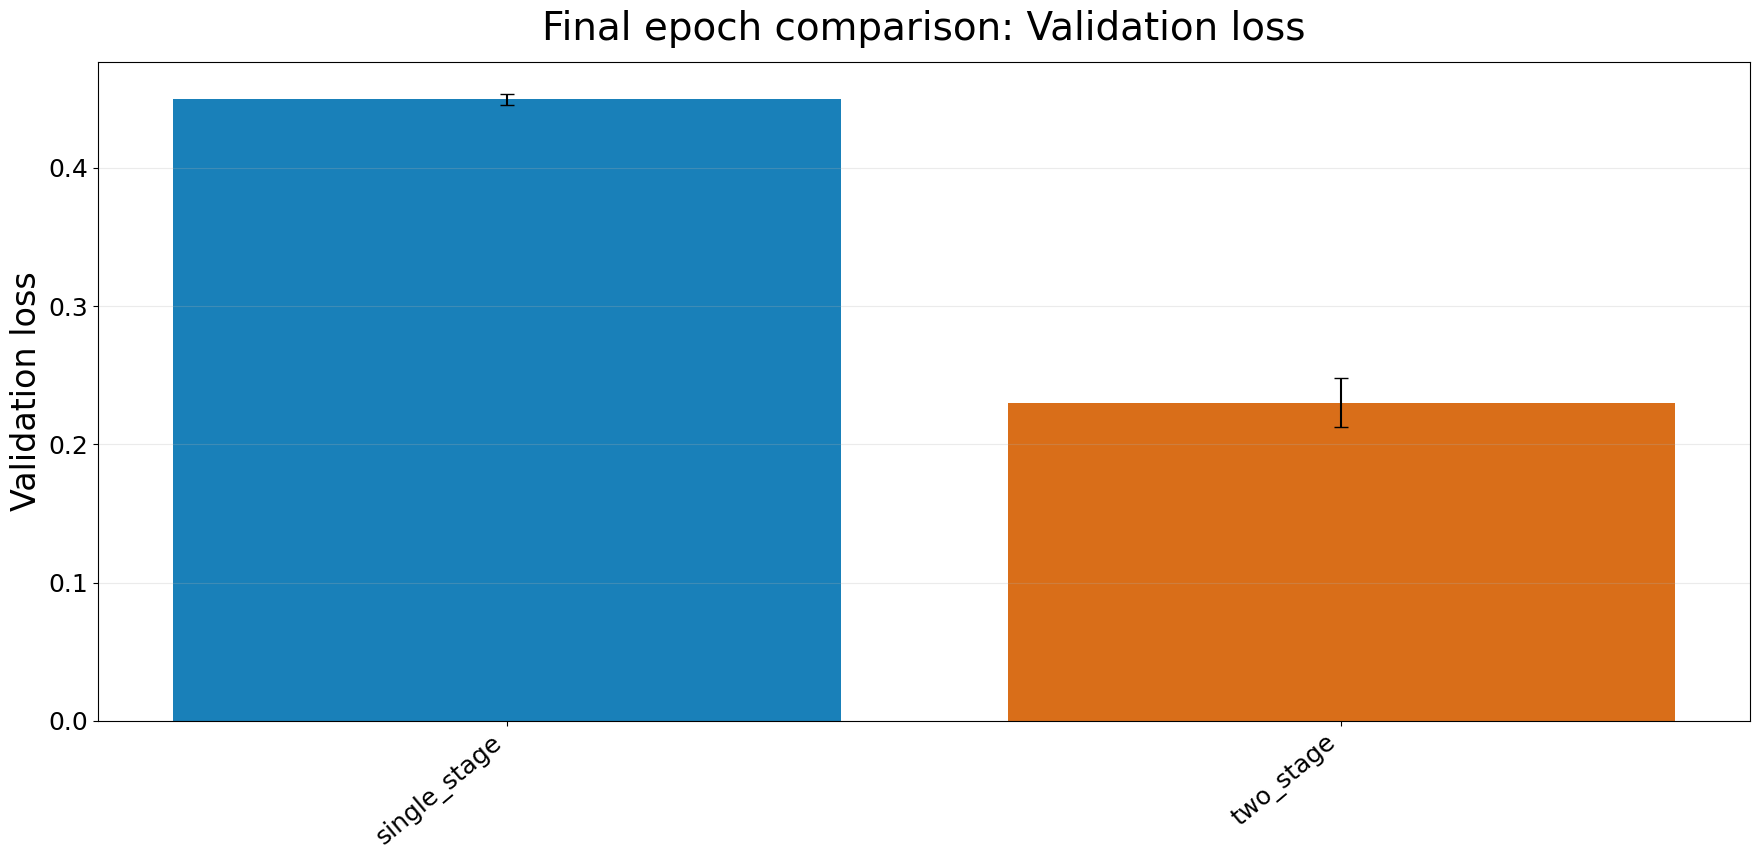

In [40]:

# =========================
# FINAL EPOCH BAR COMPARISONS
# =========================

def plot_final_epoch_comparison(all_df, metric, output_dir=None, figsize=(18, 9)):
    if all_df.empty or metric not in all_df.columns:
        print(f"[WARN] Cannot plot final comparison for {metric}.")
        return

    last_df = all_df.sort_values("epoch").groupby(["method_key", "seed"], as_index=False).tail(1)
    summary = (
        last_df.groupby(["method_key", "display_name", "approach", "augmentation"])[metric]
        .agg(["mean", "std", "count"])
        .reset_index()
        .sort_values("mean", ascending=False)
    )

    fig, ax = plt.subplots(figsize=figsize)
    x = np.arange(len(summary))
    colors = [METHOD_COLOR_MAP.get(m, "#333333") for m in summary["method_key"]]
    bars = ax.bar(x, summary["mean"], yerr=summary["std"].fillna(0), capsize=5, color=colors, alpha=0.90)

    ax.set_xticks(x)
    ax.set_xticklabels(summary["display_name"], rotation=40, ha="right")
    ax.set_ylabel(metric_titles.get(metric, metric))
    ax.set_title(f"Final epoch comparison: {metric_titles.get(metric, metric)}", pad=16)
    ax.grid(True, axis="y", alpha=0.25)

    plt.tight_layout()
    if output_dir is not None:
        save_figure(Path(output_dir) / f"final_epoch_comparison_{metric}")
    plt.show()


for metric in [m for m in ["val_macro_f1", "val_balanced_acc", "val_overall_acc", "val_loss"] if m in METRICS_TO_PLOT]:
    plot_final_epoch_comparison(all_histories, metric=metric, output_dir=OUTPUT_DIR)


In [41]:

# =========================
# CONFUSION MATRIX LOADING
# =========================

def robust_read_confusion_matrix(path: Path) -> np.ndarray:
    variants = [
        lambda p: pd.read_csv(p, header=None),
        lambda p: pd.read_csv(p),
        lambda p: pd.read_csv(p, index_col=0),
    ]
    candidates = []
    for reader in variants:
        try:
            df = reader(path)
            num = df.apply(pd.to_numeric, errors="coerce")
            num = num.dropna(axis=0, how="all").dropna(axis=1, how="all")
            arr = num.to_numpy(dtype=float)
            if arr.ndim == 2 and arr.shape[0] == arr.shape[1] and arr.shape[0] >= 2:
                candidates.append(arr)
        except Exception:
            pass
    if not candidates:
        raise ValueError(f"Could not parse confusion matrix: {path}")
    for arr in candidates:
        if arr.shape == (12, 12):
            return arr
    return candidates[0]


def load_confusion_matrices(paths: List[Path], base_dir: Path, split_name: str) -> pd.DataFrame:
    rows = []
    for p in paths:
        try:
            matrix = robust_read_confusion_matrix(p)
        except Exception as e:
            print(f"[WARN] {p}: {e}")
            continue

        info = find_nearest_seed_folder(p, base_dir)
        rows.append({
            **{k: v for k, v in info.items() if k != "original_name"},
            "split": split_name,
            "path": str(p),
            "matrix": matrix,
            "shape": matrix.shape,
        })
    return pd.DataFrame(rows)

val_cm_df = load_confusion_matrices(val_cm_paths, BASE_DIR, "validation")
test_cm_df = load_confusion_matrices(test_cm_paths, BASE_DIR, "test")
cm_df = pd.concat([val_cm_df, test_cm_df], ignore_index=True) if (not val_cm_df.empty or not test_cm_df.empty) else pd.DataFrame()

if cm_df.empty:
    print("[WARN] No confusion matrices loaded.")
else:
    display(cm_df[["split", "method_key", "display_name", "seed", "shape", "path"]].sort_values(["split", "method_key", "seed"]))


,split,method_key,display_name,seed,shape,path
5,test,single_stage_ast_mfcc_none,single_stage,67,"(12, 12)",experiments_results\experiments_improved\check...
3,test,single_stage_ast_mfcc_none,single_stage,167,"(12, 12)",experiments_results\experiments_improved\check...
4,test,single_stage_ast_mfcc_none,single_stage,267,"(12, 12)",experiments_results\experiments_improved\check...
8,test,two_stage_ast_mfcc_none,two_stage,67,"(12, 12)",experiments_results\experiments_improved\check...
6,test,two_stage_ast_mfcc_none,two_stage,167,"(12, 12)",experiments_results\experiments_improved\check...
7,test,two_stage_ast_mfcc_none,two_stage,267,"(12, 12)",experiments_results\experiments_improved\check...
2,validation,two_stage_ast_mfcc_none,two_stage,67,"(12, 12)",experiments_results\experiments_improved\check...
0,validation,two_stage_ast_mfcc_none,two_stage,167,"(12, 12)",experiments_results\experiments_improved\check...
1,validation,two_stage_ast_mfcc_none,two_stage,267,"(12, 12)",experiments_results\experiments_improved\check...


In [42]:

# =========================
# CONFUSION MATRIX AGGREGATION
# =========================

def aggregate_confusion_matrices(cm_df: pd.DataFrame) -> pd.DataFrame:
    if cm_df.empty:
        return pd.DataFrame()
    rows = []
    group_cols = ["split", "method_key", "display_name", "approach", "augmentation"]
    for keys, group in cm_df.groupby(group_cols, dropna=False):
        split, method_key, display_name, approach, augmentation = keys
        matrices = [np.asarray(m, dtype=float) for m in group["matrix"].tolist()]
        shapes = pd.Series([m.shape for m in matrices])
        common_shape = shapes.mode().iloc[0]
        matrices = [m for m in matrices if m.shape == common_shape]
        stack = np.stack(matrices, axis=0)
        rows.append({
            "split": split,
            "method_key": method_key,
            "display_name": display_name,
            "approach": approach,
            "augmentation": augmentation,
            "n_seeds": len(matrices),
            "shape": common_shape,
            "mean_matrix": stack.mean(axis=0),
            "std_matrix": stack.std(axis=0),
        })
    return pd.DataFrame(rows).sort_values(["split", "display_name"]).reset_index(drop=True)

agg_cm_df = aggregate_confusion_matrices(cm_df)
if not agg_cm_df.empty:
    display(agg_cm_df[["split", "display_name", "n_seeds", "shape"]])
    agg_cm_df[["split", "method_key", "display_name", "n_seeds", "shape"]].to_csv(OUTPUT_DIR / "confusion_matrix_summary.csv", index=False)


,split,display_name,n_seeds,shape
0,test,single_stage,3,"(12, 12)"
1,test,two_stage,3,"(12, 12)"
2,validation,two_stage,3,"(12, 12)"


Saved: experiments_results\experiments_improved\checkpoints_improved\single_stage_improved\analysis_outputs_advanced_names\confusion_matrix_validation_two_stage_normalized.png
Saved: experiments_results\experiments_improved\checkpoints_improved\single_stage_improved\analysis_outputs_advanced_names\confusion_matrix_validation_two_stage_normalized.pdf


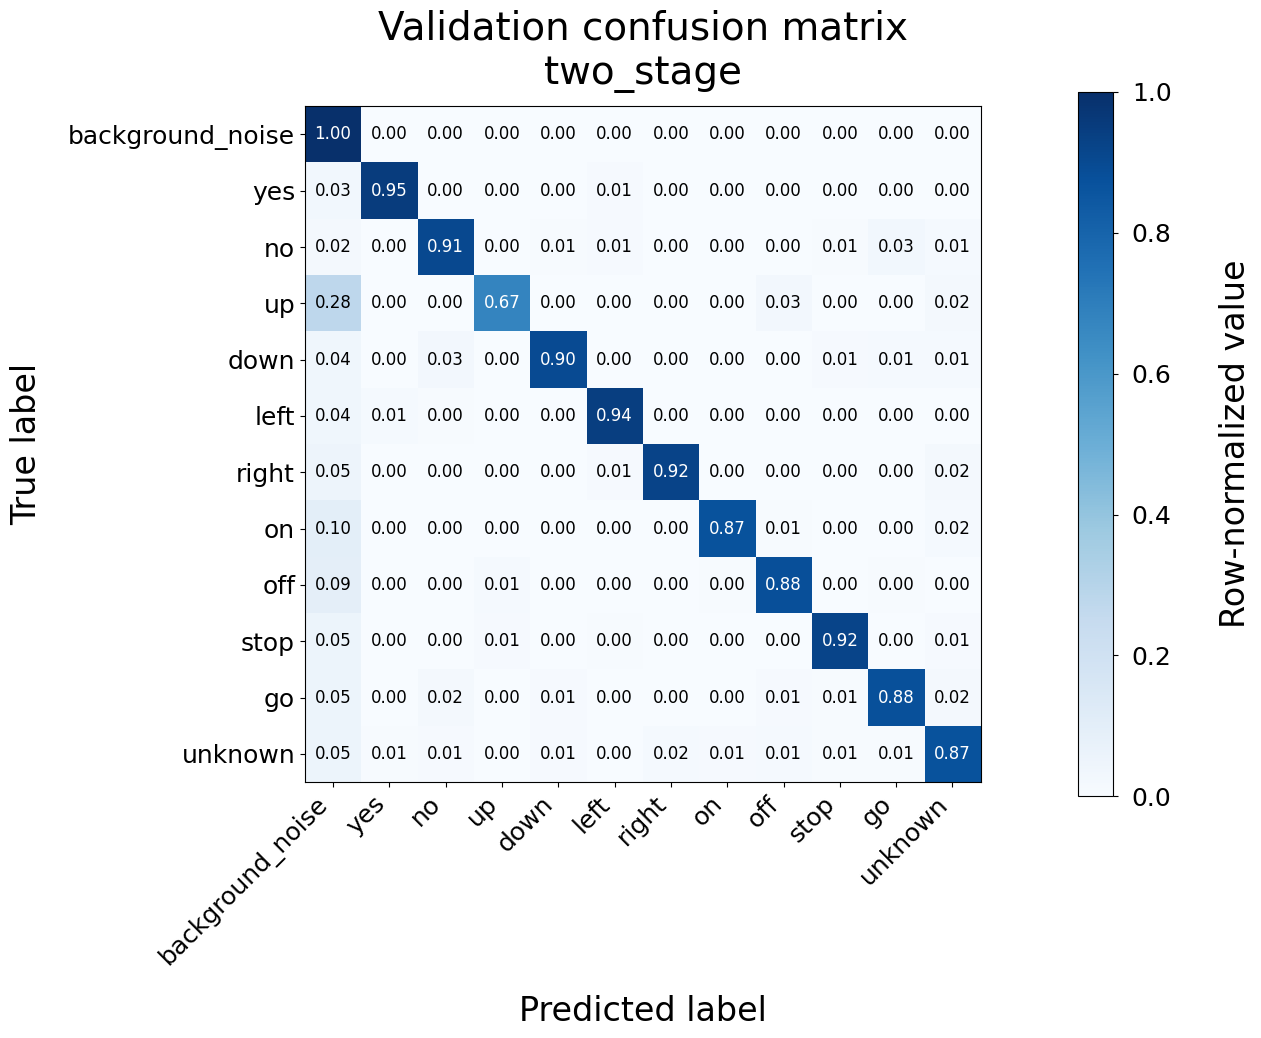

Row sums after normalization:


background_noise    1.0
yes                 1.0
no                  1.0
up                  1.0
down                1.0
left                1.0
right               1.0
on                  1.0
off                 1.0
stop                1.0
go                  1.0
unknown             1.0
dtype: float64

Saved: experiments_results\experiments_improved\checkpoints_improved\single_stage_improved\analysis_outputs_advanced_names\confusion_matrix_test_single_stage_normalized.png
Saved: experiments_results\experiments_improved\checkpoints_improved\single_stage_improved\analysis_outputs_advanced_names\confusion_matrix_test_single_stage_normalized.pdf


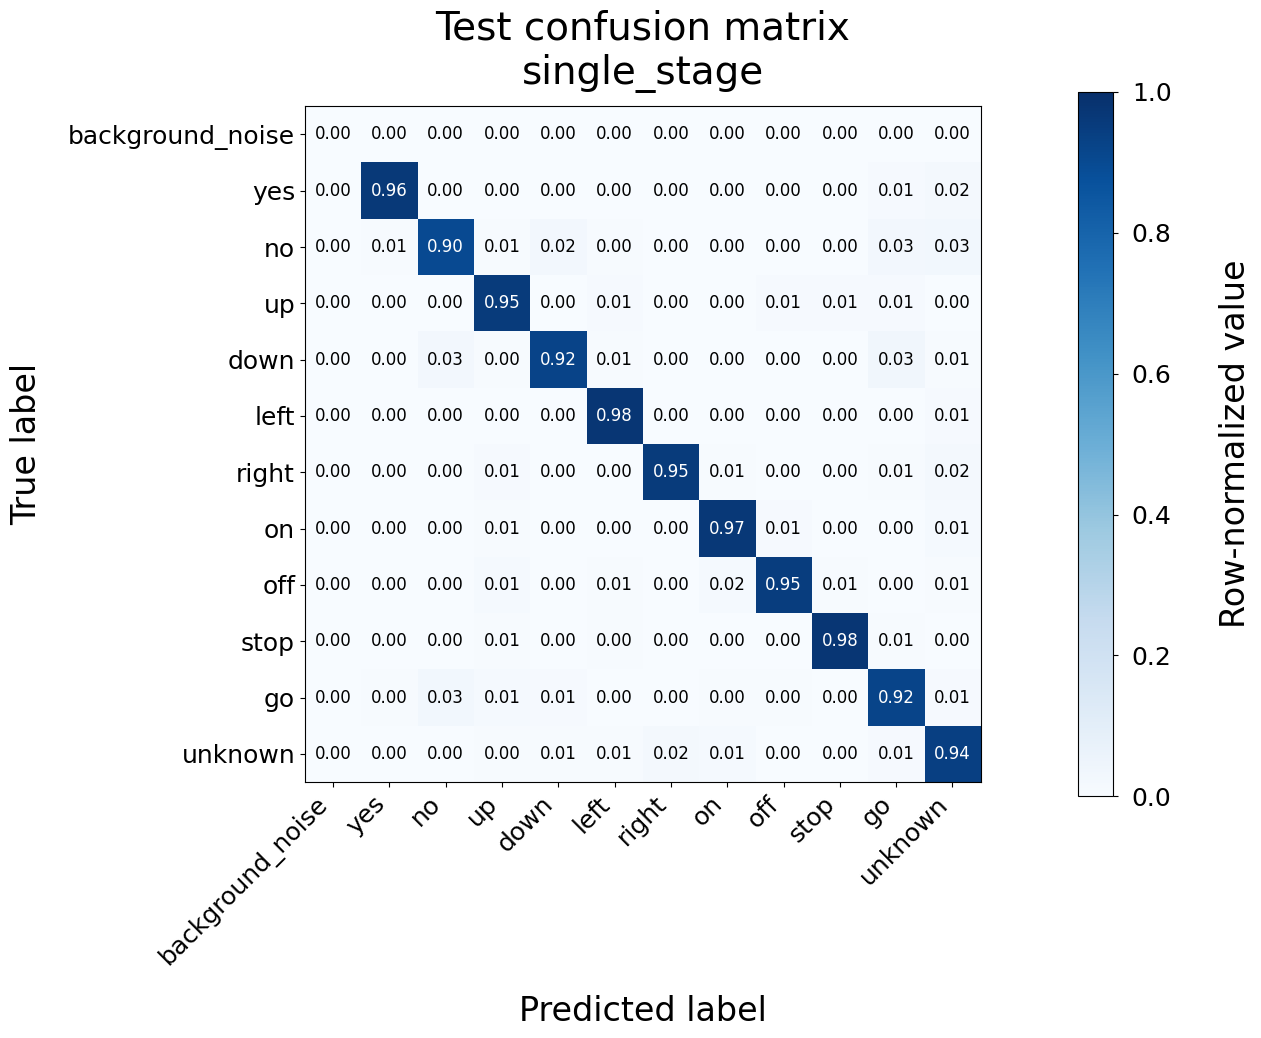

Row sums after normalization:


background_noise    0.0
yes                 1.0
no                  1.0
up                  1.0
down                1.0
left                1.0
right               1.0
on                  1.0
off                 1.0
stop                1.0
go                  1.0
unknown             1.0
dtype: float64

Rows with zero raw sum:


0    background_noise
dtype: object

Saved: experiments_results\experiments_improved\checkpoints_improved\single_stage_improved\analysis_outputs_advanced_names\confusion_matrix_test_two_stage_normalized.png
Saved: experiments_results\experiments_improved\checkpoints_improved\single_stage_improved\analysis_outputs_advanced_names\confusion_matrix_test_two_stage_normalized.pdf


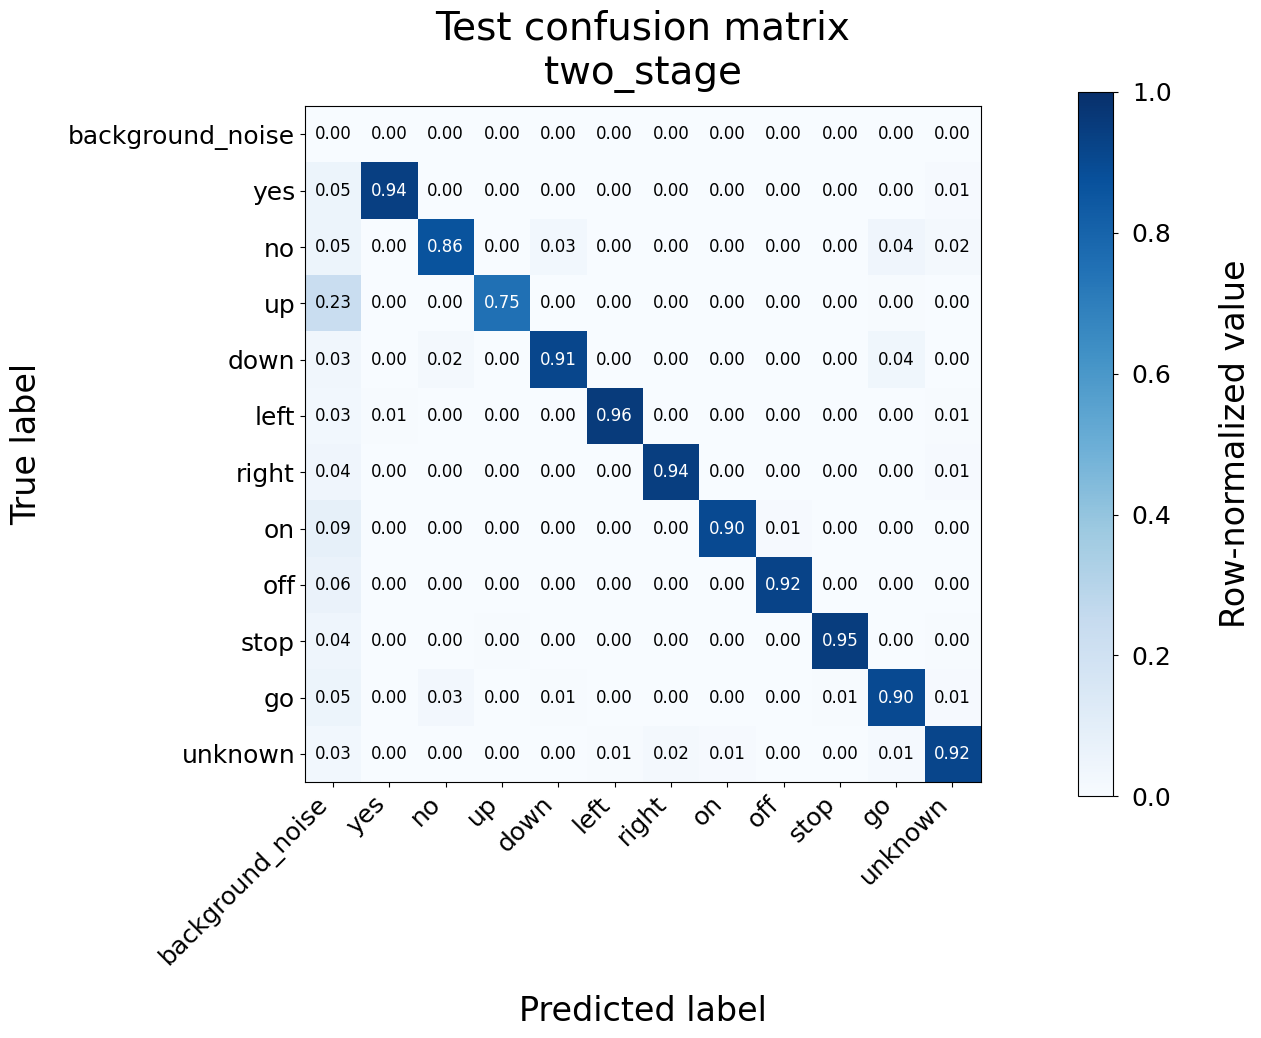

Row sums after normalization:


background_noise    0.0
yes                 1.0
no                  1.0
up                  1.0
down                1.0
left                1.0
right               1.0
on                  1.0
off                 1.0
stop                1.0
go                  1.0
unknown             1.0
dtype: float64

Rows with zero raw sum:


0    background_noise
dtype: object

In [46]:
# =========================
# CONFUSION MATRIX PLOTTING
# =========================

def row_normalize_matrix(matrix: np.ndarray) -> np.ndarray:
    """
    Row-normalize confusion matrix safely.

    Rows with sum == 0 are returned as all zeros.
    This avoids uninitialized garbage values from np.divide(where=...).
    """
    matrix = np.asarray(matrix, dtype=float)
    row_sums = matrix.sum(axis=1, keepdims=True)

    norm = np.zeros_like(matrix, dtype=float)

    np.divide(
        matrix,
        row_sums,
        out=norm,
        where=row_sums != 0,
    )

    return norm


def labels_for_matrix(n: int):
    return CLASS_NAMES if n == len(CLASS_NAMES) else [f"class_{i}" for i in range(n)]


def plot_single_confusion_matrix(
    matrix,
    title,
    normalize=True,
    annotate=True,
    output_path_base=None,
    cmap=CM_CMAP,
    figsize=(13, 11),
    print_row_sums=True,
):
    raw_matrix = np.asarray(matrix, dtype=float)

    if normalize:
        plot_matrix = row_normalize_matrix(raw_matrix)
        cbar_label = "Row-normalized value"
        value_format = ".2f"
        vmin, vmax = 0.0, 1.0
    else:
        plot_matrix = raw_matrix
        cbar_label = "Count"
        value_format = ".0f"
        vmin, vmax = None, None

    labels = labels_for_matrix(plot_matrix.shape[0])

    fig, ax = plt.subplots(figsize=figsize)

    im = ax.imshow(
        plot_matrix,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
    )

    ax.set_title(title, pad=16)
    ax.set_xlabel("Predicted label", labelpad=18)
    ax.set_ylabel("True label", labelpad=18)

    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_yticklabels(labels)

    if annotate:
        threshold = 0.55 if normalize else (plot_matrix.max() * 0.55 if plot_matrix.size else 0)

        for i in range(plot_matrix.shape[0]):
            for j in range(plot_matrix.shape[1]):
                value = plot_matrix[i, j]

                if normalize:
                    text = f"{value:.2f}"
                else:
                    text = f"{int(round(value))}"

                ax.text(
                    j,
                    i,
                    text,
                    ha="center",
                    va="center",
                    fontsize=12,
                    color="white" if value >= threshold else "black",
                )

    # Colorbar moved farther right
    cbar = fig.colorbar(
        im,
        ax=ax,
        fraction=0.046,
        pad=0.12,
    )
    cbar.set_label(cbar_label, labelpad=34)
    cbar.ax.tick_params(pad=10)

    plt.tight_layout()

    if output_path_base is not None:
        save_figure(Path(output_path_base))

    plt.show()

    if normalize and print_row_sums:
        row_sums_after = plot_matrix.sum(axis=1)
        print("Row sums after normalization:")
        display(pd.Series(row_sums_after, index=labels).round(4))

        zero_rows = raw_matrix.sum(axis=1) == 0
        if zero_rows.any():
            print("Rows with zero raw sum:")
            display(pd.Series(np.asarray(labels)[zero_rows]))


def safe_filename(name: str) -> str:
    return re.sub(r"[^a-zA-Z0-9_\-]+", "_", str(name)).strip("_")


def plot_all_confusion_matrices(agg_cm_df, split, normalize=True):
    subset = agg_cm_df[agg_cm_df["split"] == split]

    if subset.empty:
        print(f"[WARN] No matrices for split={split}")
        return

    for _, row in subset.iterrows():
        title = f"{split.capitalize()} confusion matrix\n{row['display_name']}"

        suffix = "normalized" if normalize else "raw"
        out_base = OUTPUT_DIR / f"confusion_matrix_{split}_{safe_filename(row['display_name'])}_{suffix}"

        plot_single_confusion_matrix(
            row["mean_matrix"],
            title,
            normalize=normalize,
            annotate=ANNOTATE_CM,
            output_path_base=out_base,
        )


plot_all_confusion_matrices(agg_cm_df, "validation", normalize=NORMALIZE_CM)
plot_all_confusion_matrices(agg_cm_df, "test", normalize=NORMALIZE_CM)

In [ ]:

# =========================
# VALIDATION VS TEST COMPARISON MATRICES
# =========================

def plot_validation_vs_test_for_method(agg_cm_df, method_key, normalize=True, output_dir=None, figsize=(24, 10)):
    val_row = agg_cm_df[(agg_cm_df["method_key"] == method_key) & (agg_cm_df["split"] == "validation")]
    test_row = agg_cm_df[(agg_cm_df["method_key"] == method_key) & (agg_cm_df["split"] == "test")]
    if val_row.empty or test_row.empty:
        return

    val_row = val_row.iloc[0]
    test_row = test_row.iloc[0]
    val_mat = val_row["mean_matrix"]
    test_mat = test_row["mean_matrix"]
    if normalize:
        val_mat = row_normalize_matrix(val_mat)
        test_mat = row_normalize_matrix(test_mat)
    diff = test_mat - val_mat

    labels = labels_for_matrix(val_mat.shape[0])
    mats = [val_mat, test_mat, diff]
    titles = ["Validation", "Test", "Test − validation"]
    cmaps = [CM_CMAP, CM_CMAP, DIFF_CMAP]
    vmins = [0.0 if normalize else None, 0.0 if normalize else None, -max(abs(diff.min()), abs(diff.max()))]
    vmaxs = [1.0 if normalize else None, 1.0 if normalize else None, max(abs(diff.min()), abs(diff.max()))]

    fig, axes = plt.subplots(1, 3, figsize=figsize)
    for ax, mat, title, cmap, vmin, vmax in zip(axes, mats, titles, cmaps, vmins, vmaxs):
        im = ax.imshow(mat, cmap=cmap, vmin=vmin, vmax=vmax)
        ax.set_title(title, pad=12)
        ax.set_xlabel("Predicted label")
        ax.set_ylabel("True label")
        ax.set_xticks(range(len(labels)))
        ax.set_yticks(range(len(labels)))
        ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=13)
        ax.set_yticklabels(labels, fontsize=13)

        threshold = 0.55 if title != "Test − validation" else max(abs(diff.min()), abs(diff.max())) * 0.45
        for i in range(mat.shape[0]):
            for j in range(mat.shape[1]):
                value = mat[i, j]
                text = f"{value:.2f}"
                color = "white" if abs(value) >= threshold else "black"
                ax.text(j, i, text, ha="center", va="center", fontsize=9, color=color)

        cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        cbar.ax.tick_params(labelsize=12)

    fig.suptitle(f"Validation vs test confusion matrices\n{val_row['display_name']}", y=1.03)
    plt.tight_layout()

    if output_dir is not None:
        save_figure(Path(output_dir) / f"validation_vs_test_{safe_filename(val_row['display_name'])}")
    plt.show()

if not agg_cm_df.empty:
    for method_key in sorted(agg_cm_df["method_key"].unique()):
        plot_validation_vs_test_for_method(agg_cm_df, method_key, normalize=NORMALIZE_CM, output_dir=OUTPUT_DIR)


In [ ]:

# =========================
# LARGE GRID OF ALL TEST CONFUSION MATRICES
# =========================

def plot_confusion_matrix_grid(agg_cm_df, split="test", normalize=True, output_dir=None):
    subset = agg_cm_df[agg_cm_df["split"] == split].copy()
    if subset.empty:
        print(f"[WARN] No matrices for split={split}")
        return

    n = len(subset)
    ncols = 2 if n <= 4 else 3
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(9 * ncols, 8 * nrows))
    axes = np.array(axes).reshape(-1)

    for ax, (_, row) in zip(axes, subset.iterrows()):
        mat = row["mean_matrix"]
        mat = row_normalize_matrix(mat) if normalize else mat
        labels = labels_for_matrix(mat.shape[0])
        im = ax.imshow(mat, cmap=CM_CMAP, vmin=0.0 if normalize else None, vmax=1.0 if normalize else None)
        ax.set_title(row["display_name"], fontsize=17, pad=8)
        ax.set_xlabel("Predicted", fontsize=14)
        ax.set_ylabel("True", fontsize=14)
        ax.set_xticks(range(len(labels)))
        ax.set_yticks(range(len(labels)))
        ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=10)
        ax.set_yticklabels(labels, fontsize=10)
        if ANNOTATE_CM:
            for i in range(mat.shape[0]):
                for j in range(mat.shape[1]):
                    value = mat[i, j]
                    ax.text(j, i, f"{value:.2f}", ha="center", va="center", fontsize=7,
                            color="white" if value > 0.55 else "black")

    for ax in axes[len(subset):]:
        ax.axis("off")

    fig.colorbar(im, ax=axes.tolist(), fraction=0.025, pad=0.02)
    fig.suptitle(f"Averaged {split} confusion matrices", y=1.01)
    plt.tight_layout()
    if output_dir is not None:
        save_figure(Path(output_dir) / f"confusion_matrix_grid_{split}")
    plt.show()

plot_confusion_matrix_grid(agg_cm_df, split="validation", normalize=NORMALIZE_CM, output_dir=OUTPUT_DIR)
plot_confusion_matrix_grid(agg_cm_df, split="test", normalize=NORMALIZE_CM, output_dir=OUTPUT_DIR)
